<a href="https://colab.research.google.com/github/Krishna-Dhawangale/Resume-Screening-Machine-Learning-/blob/main/SVM_Resume_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/ML_Data/AI_Resume_Screening.csv')
df.head(20)

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100
5,6,Samantha Santos,"Cybersecurity, Networking, Linux, Ethical Hacking",10,B.Tech,Google ML,Cybersecurity Analyst,Hire,47957,5,100
6,7,Tony Smith,"Networking, Cybersecurity, Ethical Hacking",4,M.Tech,AWS Certified,Cybersecurity Analyst,Hire,66208,9,100
7,8,Anthony Harrison,"TensorFlow, Pytorch, NLP",3,M.Tech,AWS Certified,AI Researcher,Hire,103006,7,90
8,9,Nancy Jenkins,"Networking, Ethical Hacking",7,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,92270,3,100
9,10,Courtney Gibson,"Python, TensorFlow, Pytorch, NLP",0,M.Tech,AWS Certified,AI Researcher,Reject,60579,1,35


In [4]:
df.shape

(1000, 11)

In [5]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,274
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


In [6]:
df.describe()

,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100)
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,4.896000,79994.486000,5.13300,83.950000
std,288.819436,3.112695,23048.472549,3.23137,20.983036
min,1.000000,0.000000,40085.000000,0.00000,15.000000
25%,250.750000,2.000000,60415.750000,2.00000,70.000000
50%,500.500000,5.000000,79834.500000,5.00000,100.000000
75%,750.250000,8.000000,99583.250000,8.00000,100.000000
max,1000.000000,10.000000,119901.000000,10.00000,100.000000


In [7]:
df['Certifications'].fillna('No Certification', inplace=True)
df['Certifications'].isnull().sum()

/tmp/ipykernel_8811/67032770.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Certifications'].fillna('No Certification', inplace=True)


np.int64(0)

In [8]:
df.isnull().sum()

,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,0
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


In [9]:
df[df.isnull().any(axis=1)]

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)


In [10]:
print(df['Job Role'].unique())

['AI Researcher' 'Data Scientist' 'Cybersecurity Analyst'
 'Software Engineer']


In [11]:
print(df['Education'].unique())

['B.Sc' 'MBA' 'B.Tech' 'PhD' 'M.Tech']


In [12]:
df.head()

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,No Certification,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,No Certification,Software Engineer,Hire,87441,9,100


In [13]:
df['Recruiter_Decision_Mapped'] = df['Recruiter Decision'].map({'Hire': 1, 'Reject': 0})
display(df.head())

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100),Recruiter_Decision_Mapped
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,No Certification,AI Researcher,Hire,104895,8,100,1
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100,1
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70,1
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95,1
4,5,Julie Hill,"SQL, React, Java",4,PhD,No Certification,Software Engineer,Hire,87441,9,100,1


In [14]:
X=df.iloc[:,:-1]
print(X)

     Resume_ID              Name  \
0            1        Ashley Ali   
1            2      Wesley Roman   
2            3     Corey Sanchez   
3            4  Elizabeth Carney   
4            5        Julie Hill   
..         ...               ...   
995        996   Brenda Williams   
996        997     Colleen Hicks   
997        998   Michelle Molina   
998        999     Danielle Horn   
999       1000      Chad Collins   

                                                Skills  Experience (Years)  \
0                             TensorFlow, NLP, Pytorch                  10   
1         Deep Learning, Machine Learning, Python, SQL                  10   
2                Ethical Hacking, Cybersecurity, Linux                   1   
3                          Python, Pytorch, TensorFlow                   7   
4                                     SQL, React, Java                   4   
..                                                 ...                 ...   
995              Cybe

In [15]:
Y=df.iloc[:,-1]
print(Y)

0      1
1      1
2      1
3      1
4      1
      ..
995    0
996    0
997    1
998    1
999    1
Name: Recruiter_Decision_Mapped, Length: 1000, dtype: int64


In [16]:
from sklearn.model_selection import train_test_split

numerical_cols = ['Experience (Years)', 'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)']
X_numerical = df[numerical_cols]

X_train, X_test, Y_train, Y_test = train_test_split(X_numerical, Y, train_size=0.7, test_size=0.3, random_state=42)

In [17]:
X_train.shape, X_test.shape

((700, 4), (300, 4))

In [18]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svc=SVC()
svc.fit(X_train,Y_train)
Y_pred_svc = svc.predict(X_test) # Renamed the prediction variable

In [19]:
accuracy=accuracy_score(Y_test,Y_pred_svc) # Corrected to use true Y_test and predicted Y_pred_svc
print(accuracy)

0.7866666666666666


In [20]:
svc = SVC(C=100.0)
svc.fit(X_train, Y_train)
Y_pred = svc.predict(X_test)

In [21]:
accuracy_score(Y_test,Y_test)

1.0

In [22]:
liner_svc=SVC(kernel='linear',C=100.0)
liner_svc.fit(X_train,Y_train)
Y_test=liner_svc.predict(X_test)

In [23]:
accuracy_score(Y_test,Y_test)

1.0

In [24]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
print('confusion Matrix')
cm=confusion_matrix(Y_test,Y_test)
print(cm)

confusion Matrix
[[ 61   0]
 [  0 239]]


In [25]:
# 1. Define numerical columns from the original DataFrame
numerical_cols = ['Experience (Years)', 'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)']
X_numerical = df[numerical_cols]
Y_true_labels = df['Recruiter_Decision_Mapped']

# 2. Re-split the data to get correct Y_test
from sklearn.model_selection import train_test_split
X_train_corrected, X_test_corrected, Y_train_corrected, Y_test_corrected = train_test_split(X_numerical, Y_true_labels, train_size=0.7, test_size=0.3, random_state=42)

# 3. Re-train the linear SVC model with corrected data
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

liner_svc_corrected = SVC(kernel='linear', C=100.0)
liner_svc_corrected.fit(X_train_corrected, Y_train_corrected)

# 4. Generate predictions using the re-trained model
Y_pred_corrected = liner_svc_corrected.predict(X_test_corrected)

# 5. Calculate and display evaluation metrics
print('Confusion Matrix:')
cm_corrected = confusion_matrix(Y_test_corrected, Y_pred_corrected)
print(cm_corrected)

print('\nClassification Report:')
report = classification_report(Y_test_corrected, Y_pred_corrected)
print(report)

accuracy_corrected = accuracy_score(Y_test_corrected, Y_pred_corrected)
print(f'\nAccuracy: {accuracy_corrected:.2f}')

Confusion Matrix:
[[ 60   4]
 [  1 235]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96        64
           1       0.98      1.00      0.99       236

    accuracy                           0.98       300
   macro avg       0.98      0.97      0.97       300
weighted avg       0.98      0.98      0.98       300


Accuracy: 0.98


In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,train_size=0.8,test_size=0.2,random_state=42)

In [27]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svc=SVC()

In [30]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

print('Evaluation for test_size = 0.2:')
print('\nConfusion Matrix:')
cm_0_2 = confusion_matrix(Y_test, Y_pred_test)
print(cm_0_2)

print('\nClassification Report:')
report_0_2 = classification_report(Y_test, Y_pred_test)
print(report_0_2)

accuracy_0_2 = accuracy_score(Y_test, Y_pred_test)
print(f'\nAccuracy: {accuracy_0_2:.2f}')

Evaluation for test_size = 0.2:

Confusion Matrix:
[[ 43   3]
 [  0 154]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        46
           1       0.98      1.00      0.99       154

    accuracy                           0.98       200
   macro avg       0.99      0.97      0.98       200
weighted avg       0.99      0.98      0.98       200


Accuracy: 0.98


In [28]:
numerical_cols = ['Experience (Years)', 'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)']
X_train_numerical = X_train[numerical_cols]
X_test_numerical = X_test[numerical_cols]

liner_svc=SVC(kernel='linear',C=100.0)
liner_svc.fit(X_train_numerical,Y_train)
Y_pred_test = liner_svc.predict(X_test_numerical)

In [29]:
# 1. Define numerical columns from the original DataFrame
numerical_cols = ['Experience (Years)', 'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)']
X_numerical = df[numerical_cols]
Y_true_labels = df['Recruiter_Decision_Mapped']

# 2. Re-split the data to get correct Y_test
from sklearn.model_selection import train_test_split
X_train_corrected, X_test_corrected, Y_train_corrected, Y_test_corrected = train_test_split(X_numerical, Y_true_labels, train_size=0.7, test_size=0.3, random_state=42)

# 3. Re-train the linear SVC model with corrected data
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

liner_svc_corrected = SVC(kernel='linear', C=100.0)
liner_svc_corrected.fit(X_train_corrected, Y_train_corrected)

# 4. Generate predictions using the re-trained model
Y_pred_corrected = liner_svc_corrected.predict(X_test_corrected)

# 5. Calculate and display evaluation metrics
print('Confusion Matrix:')
cm_corrected = confusion_matrix(Y_test_corrected, Y_pred_corrected)
print(cm_corrected)

print('\nClassification Report:')
report = classification_report(Y_test_corrected, Y_pred_corrected)
print(report)

accuracy_corrected = accuracy_score(Y_test_corrected, Y_pred_corrected)
print(f'\nAccuracy: {accuracy_corrected:.2f}')

Confusion Matrix:
[[ 60   4]
 [  1 235]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96        64
           1       0.98      1.00      0.99       236

    accuracy                           0.98       300
   macro avg       0.98      0.97      0.97       300
weighted avg       0.98      0.98      0.98       300


Accuracy: 0.98


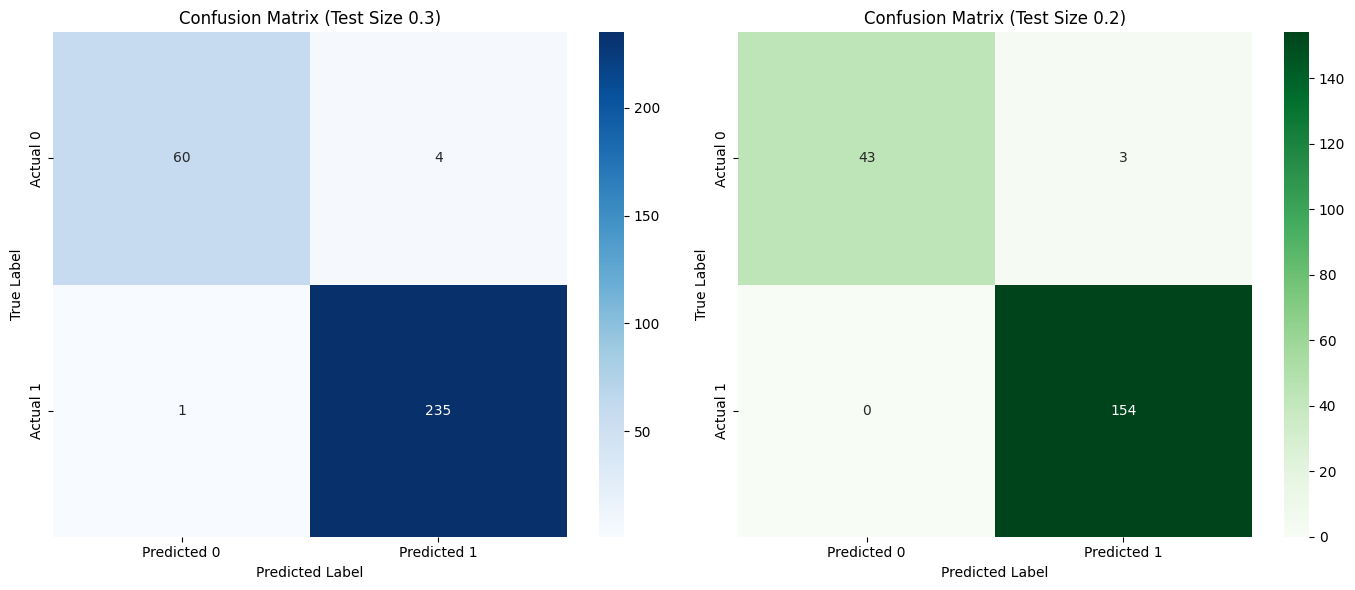

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Define numerical columns
numerical_cols = ['Experience (Years)', 'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)']
X_numerical = df[numerical_cols]
Y_true_labels = df['Recruiter_Decision_Mapped']

# --- Confusion Matrix for test_size = 0.3 ---
X_train_03, X_test_03, Y_train_03, Y_test_03 = train_test_split(X_numerical, Y_true_labels, train_size=0.7, test_size=0.3, random_state=42)

liner_svc_03 = SVC(kernel='linear', C=100.0)
liner_svc_03.fit(X_train_03, Y_train_03)
Y_pred_03 = liner_svc_03.predict(X_test_03)
cm_03 = confusion_matrix(Y_test_03, Y_pred_03)


# --- Confusion Matrix for test_size = 0.2 ---
X_train_02, X_test_02, Y_train_02, Y_test_02 = train_test_split(X_numerical, Y_true_labels, train_size=0.8, test_size=0.2, random_state=42)

liner_svc_02 = SVC(kernel='linear', C=100.0)
liner_svc_02.fit(X_train_02, Y_train_02)
Y_pred_02 = liner_svc_02.predict(X_test_02)
cm_02 = confusion_matrix(Y_test_02, Y_pred_02)


# --- Plotting the Confusion Matrices ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_03, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
axes[0].set_title('Confusion Matrix (Test Size 0.3)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_02, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
axes[1].set_title('Confusion Matrix (Test Size 0.2)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()